# Inference Notebook for Scenarios with Existing Ground Truth

**How it works:** Chose a filename for four ground truth simulation setting and a GNO checkpoint.
The Notebook will compute the GNO prediction, produce varios visualizations and compare it to the ground truth fields.

### Scenario and Setup

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from surrogate.gno.infer import infer
from surrogate.gno.graph import select_device
from utils.inference.fields import plot_scalar_field, plot_velocity_streamlines
from utils.inference.error_maps import plot_error_map
from utils.inference.io import save_predictions_npz

# --- run configuration ---
scenario = Path("data/raw/NACA_4_Digit_for_ML/test/NACA2210_n4.9_2.1e5.npz")
checkpoint = Path("checkpoints/gno_w32_d6_k16_lr0.001_NACA_4_Digit_for_ML/best.pt")
save_prediction_to = None        # set to a .npz path to save GNO predictions
device = select_device()         # cuda -> mps -> cpu

# --- run inference ---
result = infer(scenario, checkpoint, device=device)
if save_prediction_to is not None:
    save_predictions_npz(result, save_prediction_to)


Building graph (k=16)...
  1,241,216 edges  (0.1s)
Running inference...


  Done in 0.16s


## Field Visualizations

### Velocity Magnitude ($|u|_2$)

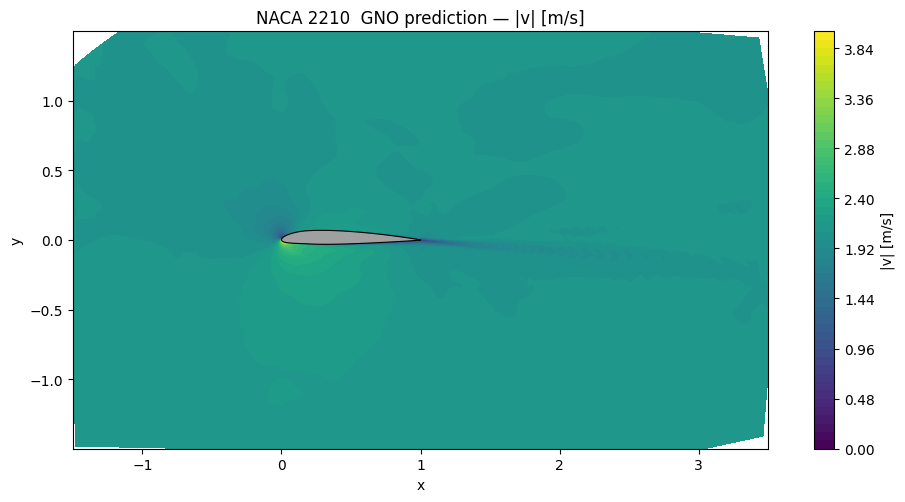

In [2]:
plot_scalar_field(result, "vel_mag")
plt.show()


### Velocity Streamlines

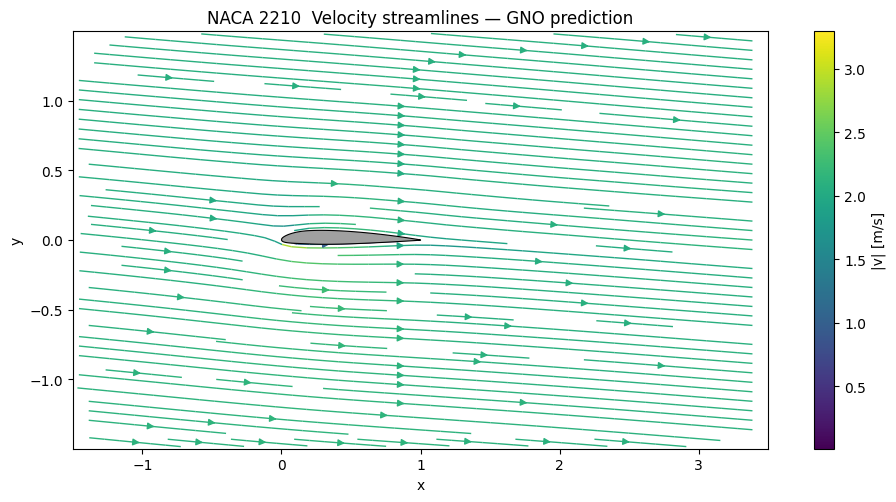

In [3]:
plot_velocity_streamlines(result)
plt.show()


### Pressure Field ($p$)

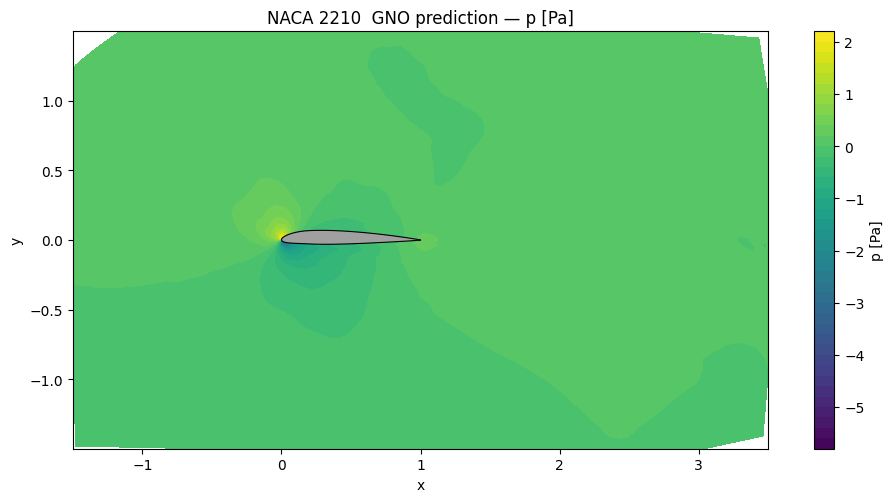

In [4]:
plot_scalar_field(result, "p")
plt.show()


### Turbulent Kinetic Energy ($k$)

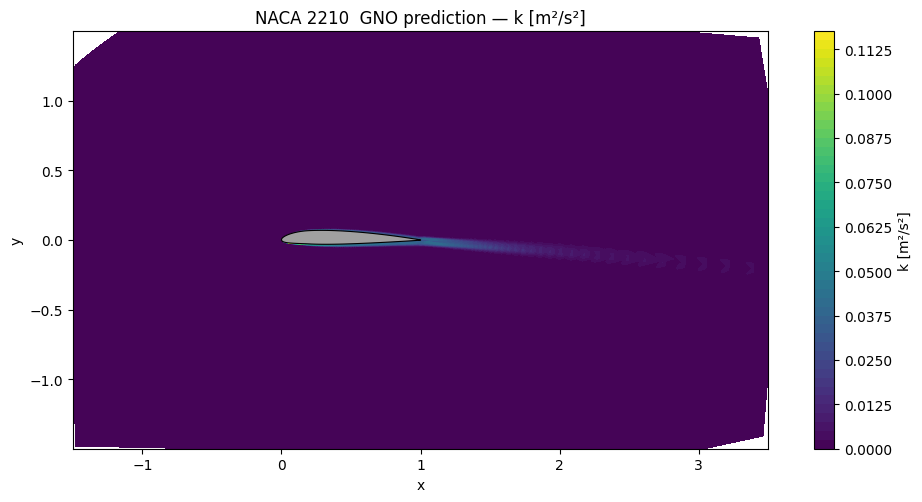

In [5]:
plot_scalar_field(result, "k")
plt.show()


### Specific Dissipation Rate ($\omega$)

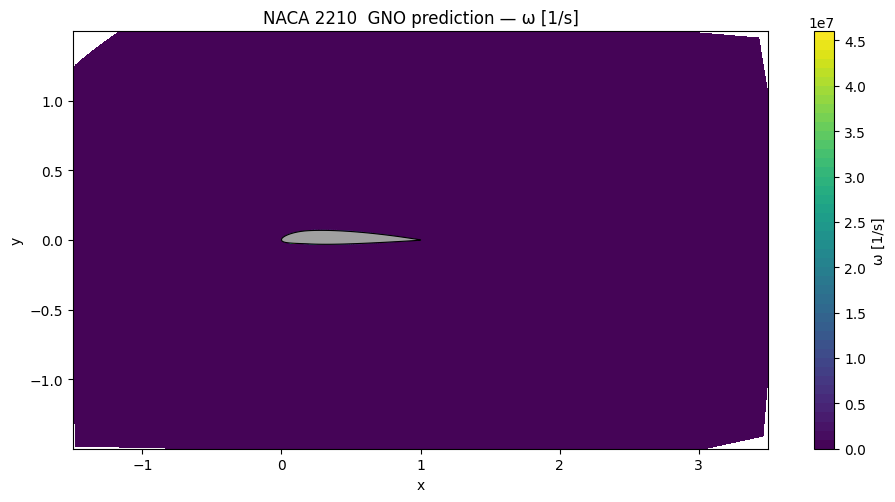

In [6]:
plot_scalar_field(result, "omega")
plt.show()


### Turbulent Viscosity ($\nu_t$)

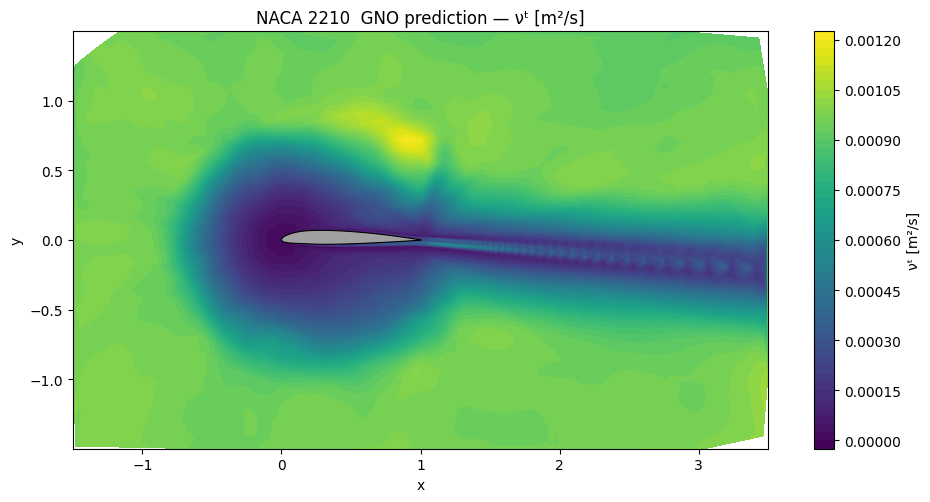

In [7]:
plot_scalar_field(result, "nut")
plt.show()


## Error Maps

### Velocity Magnitude ($|u|_2$)

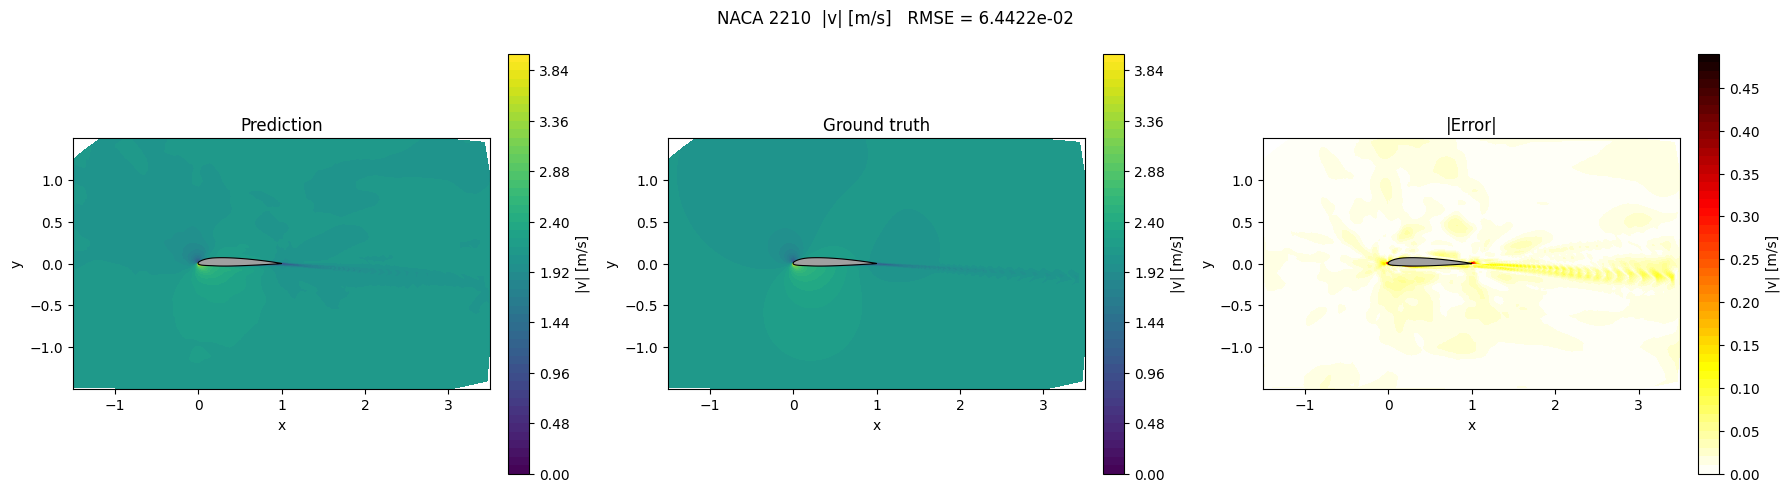

In [8]:
plot_error_map(result, "vel_mag")
plt.show()


### Pressure Field ($p$)

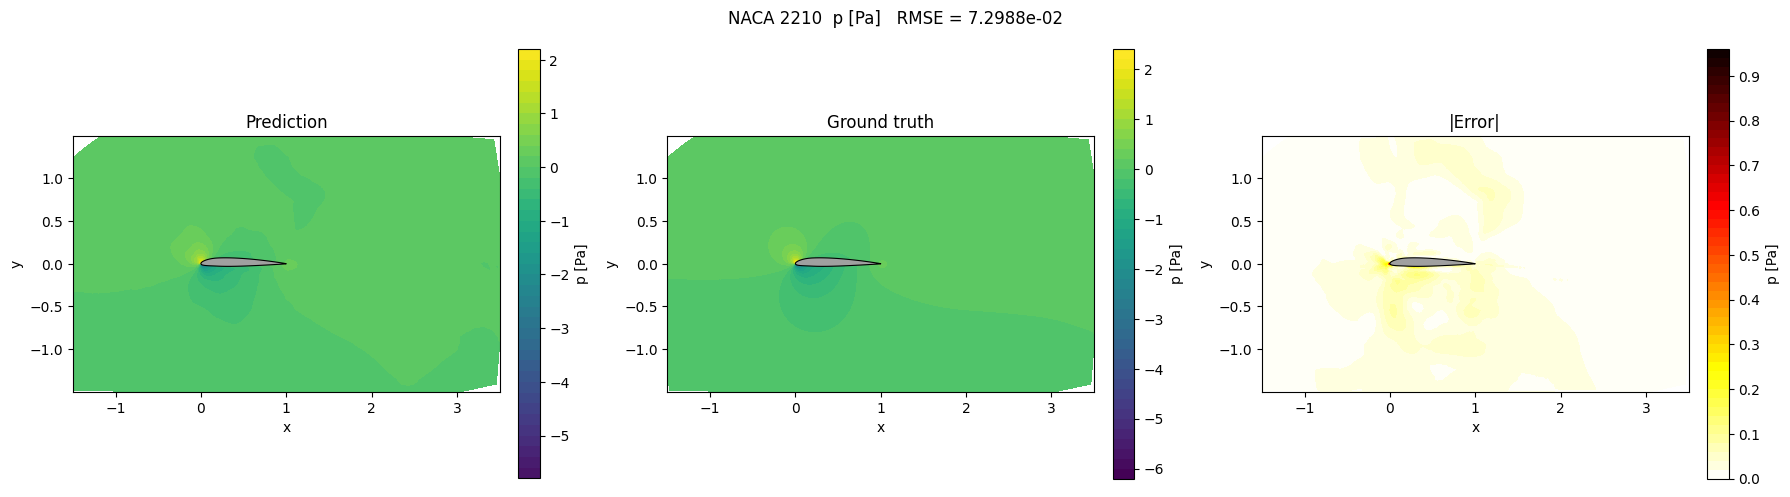

In [9]:
plot_error_map(result, "p")
plt.show()


### Turbulent Kinetic Energy ($k$)

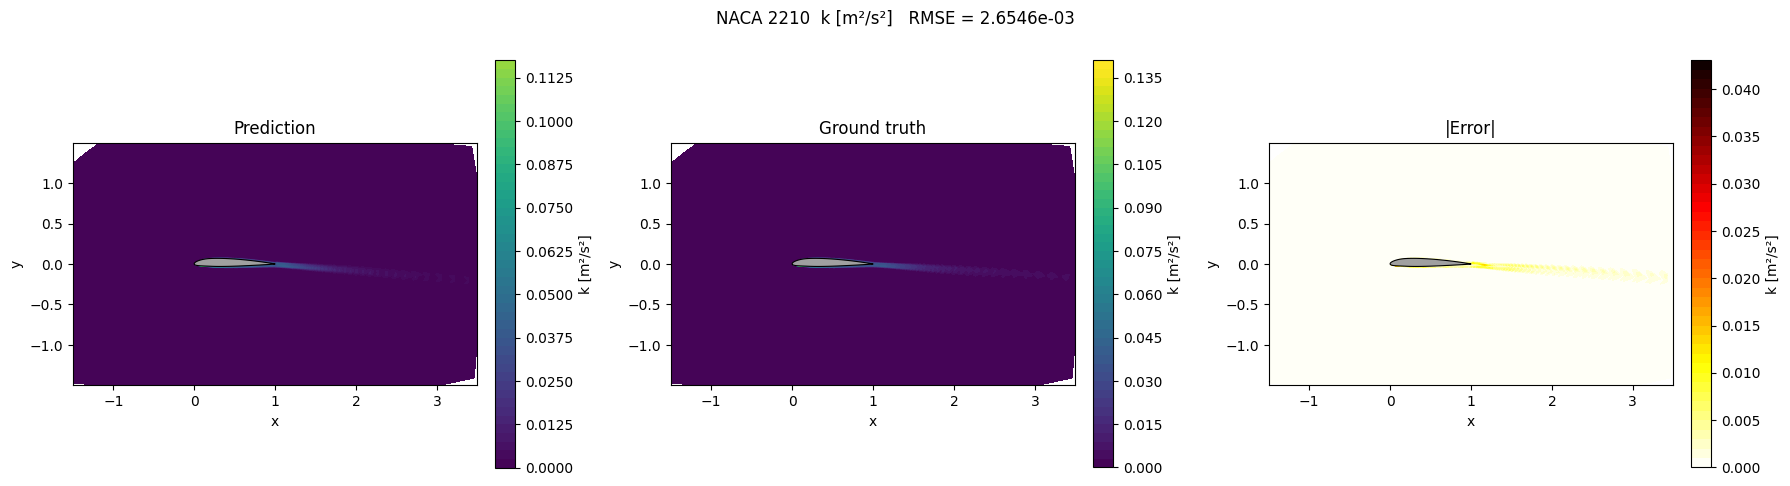

In [10]:
plot_error_map(result, "k")
plt.show()


### Specific Dissipation Rate ($\omega$)

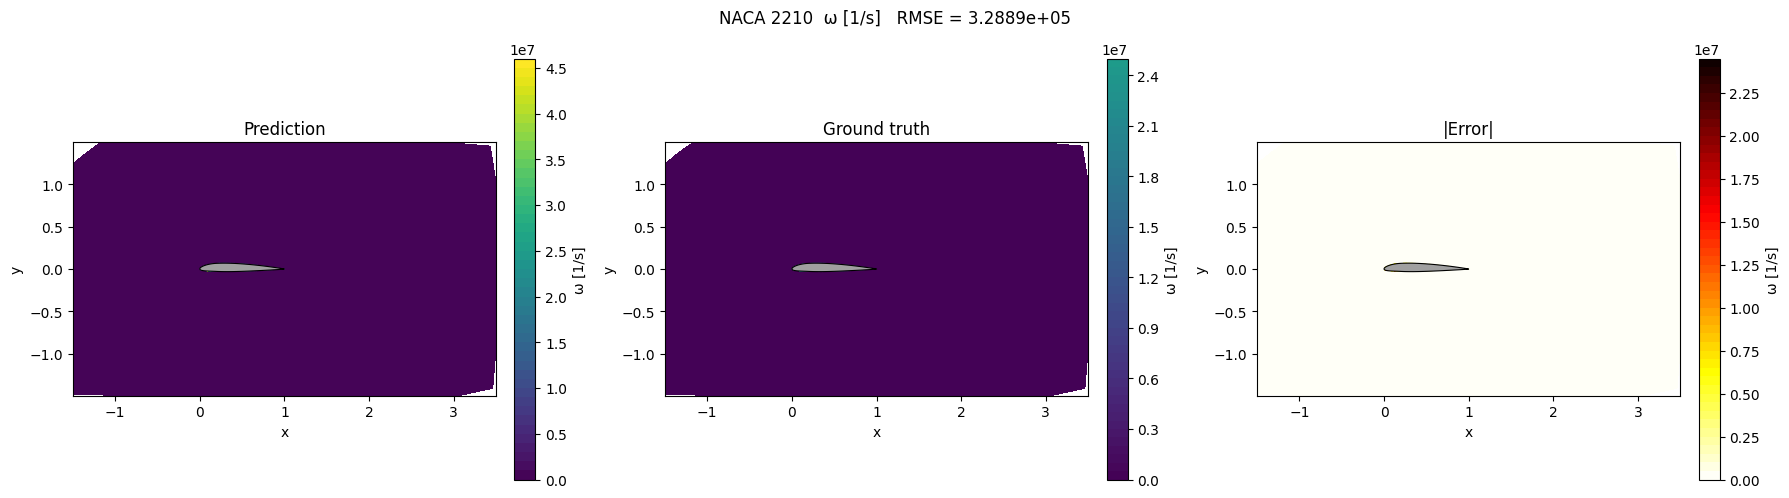

In [11]:
plot_error_map(result, "omega")
plt.show()


### Turbulent Viscosity ($\nu_t$)

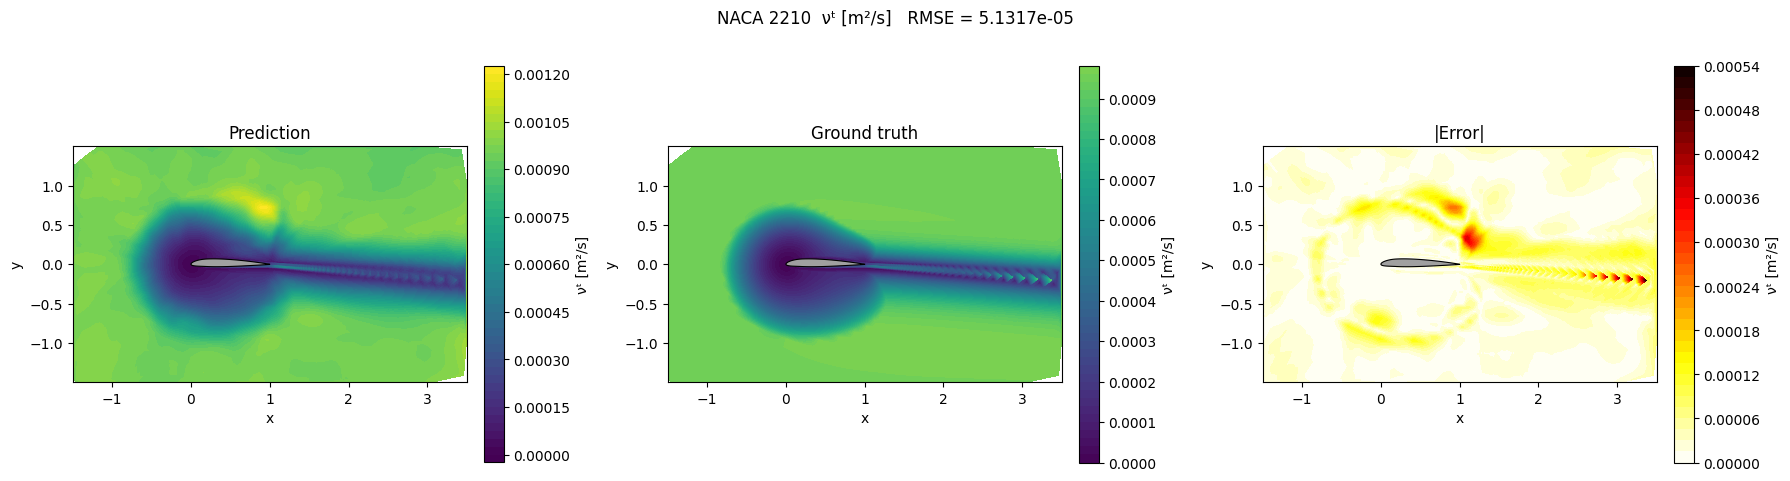

In [12]:
plot_error_map(result, "nut")
plt.show()
